# Solution: Identify land use from aerial images using Convolutional Neural Networks - Part 1
## Basic CNN architecture

This notebook explores the method to find an optimal CNN. Note that there are many optimal solutions and yours may differ. This notebook is meant to showcase the process and intuition.

## Set Up
We begin by setting up the environment and loading in the data from Google Drive. You can skip this part and continue to the model definition.

In [ ]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchsummary import summary

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Connect to Google Colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
folder_path = '/content/drive/MyDrive/Colab Notebooks/data/'
%cd "$folder_path"

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1boy-gFID3nvWPeLsN4uWeEvAbDL-xlNV/data


In [ ]:
# Check if CUDA is available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


We will load the entire data set so that we can try to push our model to high accuracies.

In [ ]:
df = pd.read_csv('labels.csv')

image_paths = df['image'].values
labels = df['label'].values
num_classes = 21

label_mapping = {}
with open('label_mapping.txt', 'r') as file:
    for line in file:
        value, key = line.strip().split(': ')
        label_mapping[int(key)] = value

# Split the data for 70% training, 15% test set, 15% validation set
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.30, random_state=42)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    test_paths, test_labels, test_size=0.5, random_state=42)

def load_images(file_paths, transform, folder_path='Images/'):
    images = []
    for file_path in tqdm(file_paths, desc='Loading images'):
        # Load the image
        with Image.open(folder_path+file_path) as img:
            # Convert image to RGB if it's not and apply the same basic transformations
            img = img.convert('RGB')
            img = transform(img)
            images.append(img)
    return torch.stack(images)

def calculate_mean_std(stacked_images):
    # Mean and std are calculated across the height and width dimensions (2 and 3)
    mean = stacked_images.view(stacked_images.size(0), stacked_images.size(1), -1).mean(dim=2).mean(dim=0)
    std = stacked_images.view(stacked_images.size(0), stacked_images.size(1), -1).std(dim=2).mean(dim=0)
    return mean, std

basic_transform = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),        # 224x224 is a common "historical" format for benchmarking CNNs
    transforms.ToTensor()
])

train_images = load_images(train_paths, basic_transform)
mean, std = calculate_mean_std(train_images)
normalize_transform = transforms.Normalize(mean=mean, std=std)
train_images = torch.stack([normalize_transform(image) for image in train_images])

Loading images: 100%|██████████| 1470/1470 [08:06<00:00,  3.02it/s]


In [ ]:
# Transformation with normalization for validation and test dataset
transform = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),        # 224x224 is a common "historical" format for benchmarking CNNs
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load and normalize the validation and test datasets
val_images = load_images(val_paths, transform)
test_images = load_images(test_paths, transform)

# Convert labels to tensors
train_labels = torch.tensor(train_labels)
val_labels = torch.tensor(val_labels)
test_labels = torch.tensor(test_labels)

# Create TensorDatasets
train_dataset = TensorDataset(train_images, train_labels)
val_dataset = TensorDataset(val_images, val_labels)
test_dataset = TensorDataset(test_images, test_labels)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Loading images: 100%|██████████| 315/315 [01:44<00:00,  3.02it/s]


# Finding the Optimal CNN Model
Lets start off with the BasicCNN provided, defined below. It has six convolutional layers and six pooling layers.

In [ ]:
# Define the CNN architecture
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super(BasicCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        # pooling has no learnable parameters, so we can just use one
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # MLP classifier
        self.fc = nn.Linear(128 * 3 * 3, num_classes)

    def forward(self, x):
        # print("Input size:", x.size())
        x = self.pool(F.relu(self.conv1(x)))
        # print("Layer size:", x.size())
        x = self.pool(F.relu(self.conv2(x)))
        # print("Layer size:", x.size())
        x = self.pool(F.relu(self.conv3(x)))
        # print("Layer size:", x.size())
        x = self.pool(F.relu(self.conv4(x)))
        # print("Layer size:", x.size())
        x = self.pool(F.relu(self.conv5(x)))
        # print("Layer size:", x.size())
        x = self.pool(F.relu(self.conv6(x)))
        # print("Layer size:", x.size())
        x = x.view(-1, 128 * 3 * 3)  # Flatten the tensor
        # print("Layer size:", x.size())

        # Fully connected layer for classification
        x = self.fc(x)

        return x

In [ ]:
# Instantiate the basic CNN
model = BasicCNN(num_classes=num_classes).to(device)
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
         MaxPool2d-2         [-1, 32, 112, 112]               0
            Conv2d-3         [-1, 64, 112, 112]          18,496
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5          [-1, 128, 56, 56]          73,856
         MaxPool2d-6          [-1, 128, 28, 28]               0
            Conv2d-7          [-1, 128, 28, 28]         147,584
         MaxPool2d-8          [-1, 128, 14, 14]               0
            Conv2d-9          [-1, 128, 14, 14]         147,584
        MaxPool2d-10            [-1, 128, 7, 7]               0
           Conv2d-11            [-1, 128, 7, 7]         147,584
        MaxPool2d-12            [-1, 128, 3, 3]               0
           Linear-13                   [-1, 21]          24,213
Total params: 560,213
Trainable params:

## Basic CNN Evaluation

For the training of the model, we will keep track of the following metrics in a dictionary:
- Trianing Loss
- Validation Loss
- Validation Accuracy
- Validation Precision
- Validation Recall
- Validation F1 Score

This is beneficial when searching for an optimal model because it paints a bigger picture than just accuracy. We will later plot this to inspect the results.

### Training loop



In [ ]:
criterion = nn.CrossEntropyLoss()
def train(model, train_loader, path = '/best_model.pth', lr=0.005, num_epochs=5):
  # Define loss function, optimizer and training epochs
  optimizer = optim.AdamW(model.parameters(), lr=lr)


  # Initialize the metrics
  metrics = {'training losses' : [],
             'validation losses' : [],
             'validation accuracies' : [],
             'validation precisions' : [],
             'validation recalls' : [],
             'validation f1 scores' : []}


  # We keep track of the best validation accuracy and save the best model
  best_val_accuracy = 0.0

  # Training loop
  for epoch in range(num_epochs):
      model.train()
      training_loss = 0.0
      for images, labels in train_loader:
          images, labels = images.to(device), labels.to(device)
          optimizer.zero_grad()
          outputs = model(images)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()
          training_loss += loss.item()

      # Store average training loss for the epoch
      metrics['training losses'].append(training_loss/len(train_loader))

      # Validation loop
      model.eval()
      validation_loss = 0.0
      true_labels = []
      predicted_labels = []

      with torch.no_grad():
          for images, labels in val_loader:
              images, labels = images.to(device), labels.to(device)
              outputs = model(images)
              loss = criterion(outputs, labels)
              validation_loss += loss.item()
              _, predicted = torch.max(outputs.data, 1)

              true_labels.extend(labels.cpu().numpy())
              predicted_labels.extend(predicted.cpu().numpy())

      # Calculate validation loss
      metrics['validation losses'].append(validation_loss / len(val_loader))

      # Calculate metrics
      accuracy = 100*accuracy_score(true_labels, predicted_labels)
      precision = 100*precision_score(true_labels, predicted_labels, average='weighted', zero_division=1)
      recall = 100*recall_score(true_labels, predicted_labels, average='macro')
      f1 = 100*f1_score(true_labels, predicted_labels, average='weighted')

      # Store metrics
      metrics['validation accuracies'].append(accuracy)
      metrics['validation precisions'].append(precision)
      metrics['validation recalls'].append(recall)
      metrics['validation f1 scores'].append(f1)

      # save best model based on validation accuracy
      if accuracy > best_val_accuracy:
          best_val_accuracy = accuracy
          torch.save(model.state_dict(), path)
          print(f"Epoch {epoch+1}: Improved validation accuracy to {best_val_accuracy:.2f}%. Model saved.")

      print(f'Epoch {epoch+1}/{num_epochs}', f'Train Loss: {metrics["training losses"][-1]:.4f}, '
          f'Validation Loss: {metrics["validation losses"][-1]:.4f}, '
          f'Accuracy: {metrics["validation accuracies"][-1]:.2f}%')

  return metrics

In [ ]:
metrics = train(model, train_loader, num_epochs=10)
# Load the best model after training is complete
model.load_state_dict(torch.load('/best_model.pth'))
print("Loaded best model from:", '/best_model.pth')
print(metrics)

Epoch 1: Improved validation accuracy to 8.57%. Model saved.
Epoch 1/10 Train Loss: 3.4391, Validation Loss: 2.9408, Accuracy: 8.57%
Epoch 2: Improved validation accuracy to 16.51%. Model saved.
Epoch 2/10 Train Loss: 2.7769, Validation Loss: 2.4978, Accuracy: 16.51%
Epoch 3: Improved validation accuracy to 24.44%. Model saved.
Epoch 3/10 Train Loss: 2.3412, Validation Loss: 2.3268, Accuracy: 24.44%
Epoch 4: Improved validation accuracy to 25.71%. Model saved.
Epoch 4/10 Train Loss: 2.1502, Validation Loss: 2.3101, Accuracy: 25.71%
Epoch 5: Improved validation accuracy to 32.70%. Model saved.
Epoch 5/10 Train Loss: 1.9692, Validation Loss: 2.0331, Accuracy: 32.70%
Epoch 6: Improved validation accuracy to 42.22%. Model saved.
Epoch 6/10 Train Loss: 1.7302, Validation Loss: 1.8958, Accuracy: 42.22%
Epoch 7: Improved validation accuracy to 47.30%. Model saved.
Epoch 7/10 Train Loss: 1.5067, Validation Loss: 1.7785, Accuracy: 47.30%
Epoch 8: Improved validation accuracy to 53.02%. Model sa

### Plotting losses and accuracies

In [ ]:
def visualize(metrics):
  cpu_metrics = {'training losses' : [],
             'validation losses' : [],
             'validation accuracies' : [],
             'validation precisions' : [],
             'validation recalls' : [],
             'validation f1 scores' : []}

  for key, values in metrics.items():
    cpu_metrics[key] = [val.cpu().item() if hasattr(val, 'cpu') else val for val in values]


  losses = ['training losses', 'validation losses']
  other_metrics = ['validation accuracies', 'validation precisions', 'validation recalls', 'validation f1 scores']

  # Create figure and subplots
  fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

  # Plot for losses
  axs[0].set_title('Losses')
  for metric in losses:
      axs[0].plot(cpu_metrics[metric], label=metric)
  axs[0].set_xlabel('Epochs')
  axs[0].set_ylabel('Value')
  axs[0].legend()
  axs[0].grid(True)

  # Instantiate a second y-axis sharing the same x-axis
  ax2 = axs[0].twinx()
  ax2.plot(cpu_metrics['validation accuracies'], 'r-', label='Validation Accuracy')
  ax2.set_ylabel('Accuracy (%)')
  ax2.tick_params(axis='y')
  ax2.legend(loc='upper left')

  # Plot for other metrics
  axs[1].set_title('Other Metrics')
  for metric in other_metrics:
      axs[1].plot(cpu_metrics[metric], label=metric)
  axs[1].set_xlabel('Epochs')
  axs[1].set_ylabel('Value')
  axs[1].legend()
  axs[1].grid(True)

  plt.tight_layout()
  plt.show()

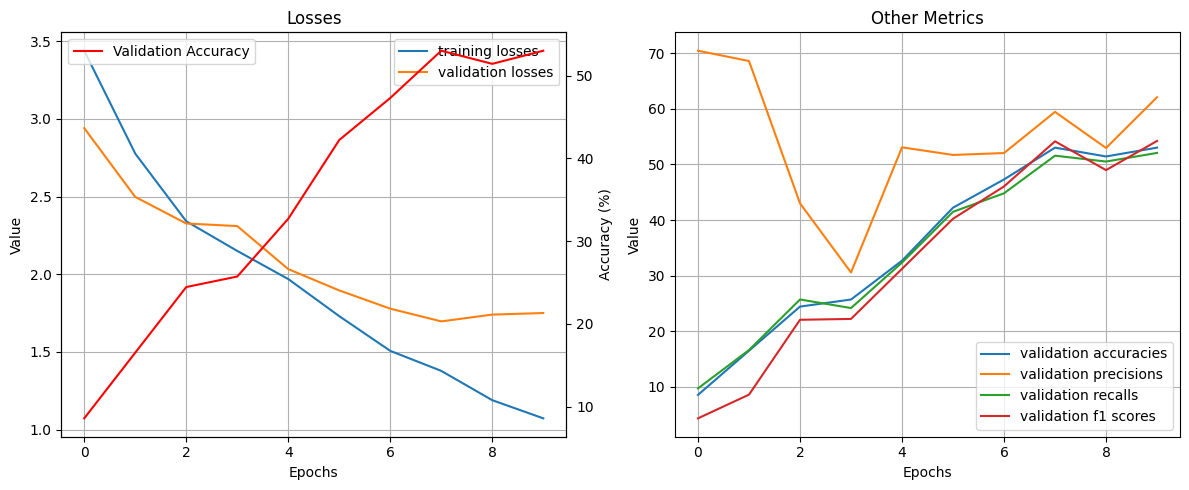

In [ ]:
visualize(metrics)

## Evaluation on the Test Dataset

In [ ]:
def test(model, test_loader):
  # Test loop
  model.eval()
  test_loss = 0.0
  correct = 0
  total = 0
  true_labels = []
  predicted_labels = []
  with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = criterion(outputs, labels)
          test_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)

          true_labels.extend(labels.cpu().numpy())
          predicted_labels.extend(predicted.cpu().numpy())

  # Calculate metrics
  accuracy = 100*accuracy_score(true_labels, predicted_labels)
  precision = 100*precision_score(true_labels, predicted_labels, average='weighted', zero_division=1)
  recall = 100*recall_score(true_labels, predicted_labels, average='weighted')
  f1 = 100*f1_score(true_labels, predicted_labels, average='weighted')

  # Update progress bar with stats
  print(f'Accuracy: {accuracy:.2f}%, Precision: {precision:.2f}%, Recall: {recall:.2f}%, F1 Score: {f1:.2f}%')

In [ ]:
test(model, test_loader)

Accuracy: 50.79%, Precision: 56.07%, Recall: 50.79%, F1 Score: 50.70%


### Analysis of Basic CNN
We can see that the model performs already quite well already, but there are many things we can improve. Some ideas are:
- Increase number of epochs/ decreasing learning rate
- Making the model deeper
- Varying the kernel sizes

We will start off with adding more layers, and since this makes the model more complex, we will train it for longer with a low learning rate.

## Adding More Layers
Lets see what happens if we increase the number of layers. Note that since we start off with a 224x224 image, we have to stack convolutional layers between pooling as our spatial dimensions would otherwise reduce to 0 x 0. Lets see how adding more layers affects the model.

In [ ]:
class DeeperCNN(nn.Module):
    def __init__(self, num_classes):
        super(DeeperCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)

        # Pooling layers
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # MLP classifier
        self.fc = nn.Linear(256 * 14 * 14, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)

        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool(x)

        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))
        x = self.pool(x)

        x = x.view(-1, 256 * 14 * 14)  # Flatten the tensor

        x = self.fc(x)

        return x

In [ ]:
deeperCNN = DeeperCNN(num_classes=num_classes).to(device)
summary(deeperCNN, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
            Conv2d-2         [-1, 64, 224, 224]          18,496
         MaxPool2d-3         [-1, 64, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]          36,928
            Conv2d-5         [-1, 64, 112, 112]          36,928
         MaxPool2d-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1, 128, 56, 56]          73,856
            Conv2d-8          [-1, 256, 56, 56]         295,168
         MaxPool2d-9          [-1, 256, 28, 28]               0
           Conv2d-10          [-1, 256, 28, 28]         590,080
           Conv2d-11          [-1, 256, 28, 28]         590,080
        MaxPool2d-12          [-1, 256, 14, 14]               0
           Linear-13                   [-1, 21]       1,053,717
Total params: 2,696,149
Trainable param

In [ ]:
deeperCNN = DeeperCNN(num_classes=num_classes).to(device)
metrics2 = train(deeperCNN, train_loader, lr=0.0005, num_epochs=10)
# Load the best model after training is complete
deeperCNN.load_state_dict(torch.load('/best_model.pth'))
print("Loaded best model from:", '/best_model.pth')

Epoch 1: Improved validation accuracy to 16.19%. Model saved.
Epoch 1/10 Train Loss: 2.9591, Validation Loss: 2.6628, Accuracy: 16.19%
Epoch 2: Improved validation accuracy to 29.52%. Model saved.
Epoch 2/10 Train Loss: 2.3743, Validation Loss: 2.1861, Accuracy: 29.52%
Epoch 3/10 Train Loss: 2.1068, Validation Loss: 2.4283, Accuracy: 25.08%
Epoch 4: Improved validation accuracy to 40.95%. Model saved.
Epoch 4/10 Train Loss: 1.7164, Validation Loss: 1.7861, Accuracy: 40.95%
Epoch 5: Improved validation accuracy to 41.27%. Model saved.
Epoch 5/10 Train Loss: 1.2796, Validation Loss: 2.0276, Accuracy: 41.27%
Epoch 6: Improved validation accuracy to 46.03%. Model saved.
Epoch 6/10 Train Loss: 1.0061, Validation Loss: 1.6859, Accuracy: 46.03%
Epoch 7: Improved validation accuracy to 49.84%. Model saved.
Epoch 7/10 Train Loss: 0.6980, Validation Loss: 1.9991, Accuracy: 49.84%
Epoch 8/10 Train Loss: 0.4434, Validation Loss: 2.4613, Accuracy: 47.30%
Epoch 9/10 Train Loss: 0.4082, Validation Lo

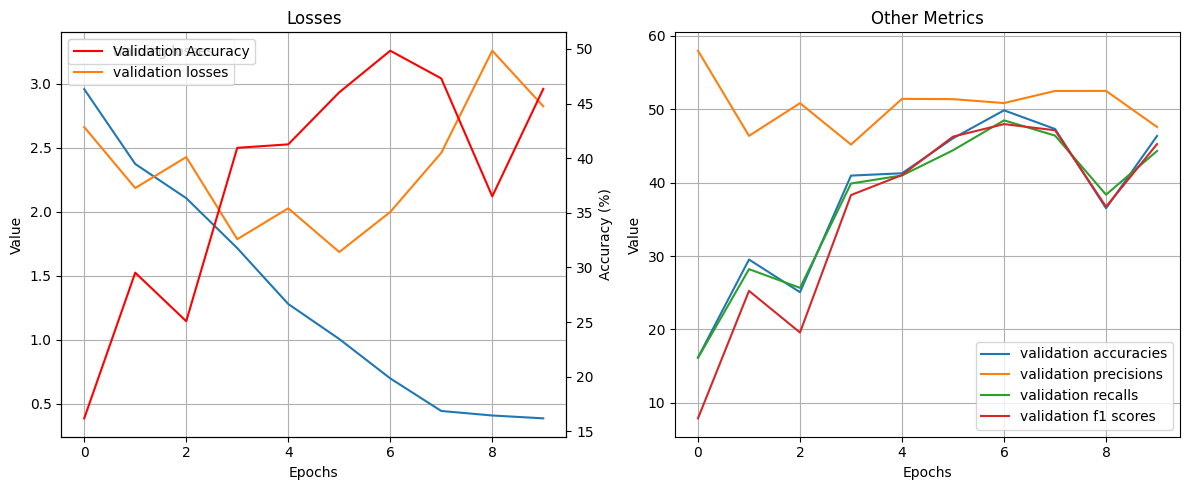

Accuracy: 57.46%, Precision: 60.06%, Recall: 57.46%, F1 Score: 56.46%


In [ ]:
visualize(metrics2)
test(deeperCNN, test_loader)

## Analysis of More Layers Model
We can see that the deeper model performs slightly better but it stops learning very quickly, so it is not quite ideal.

## Expanding on the Previous Model
We can make the model slightly deeper by adding another convolutional block and lower the learning rate by a factor of 10. Lets see if this helps our model continue to learn.

In [ ]:
class EvenDeeperCNN(nn.Module):
    def __init__(self, num_classes):
        super(EvenDeeperCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        # Pooling layers
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # MLP classifier
        self.fc = nn.Linear(512 * 7 * 7, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)

        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool(x)

        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))
        x = self.pool(x)

        x = F.relu(self.conv9(x))
        x = F.relu(self.conv10(x))
        x = self.pool(x)

        x = x.view(-1, 512 * 7 * 7)  # Flatten the tensor

        x = self.fc(x)

        return x

In [ ]:
even_deeper_CNN = EvenDeeperCNN(num_classes=num_classes).to(device)
summary(even_deeper_CNN, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
            Conv2d-2         [-1, 64, 224, 224]          18,496
         MaxPool2d-3         [-1, 64, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]          36,928
            Conv2d-5         [-1, 64, 112, 112]          36,928
         MaxPool2d-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1, 128, 56, 56]          73,856
            Conv2d-8          [-1, 128, 56, 56]         147,584
         MaxPool2d-9          [-1, 128, 28, 28]               0
           Conv2d-10          [-1, 256, 28, 28]         295,168
           Conv2d-11          [-1, 256, 28, 28]         590,080
        MaxPool2d-12          [-1, 256, 14, 14]               0
           Conv2d-13          [-1, 512, 14, 14]       1,180,160
           Conv2d-14          [-1, 512,

In [ ]:
even_deeper_CNN = EvenDeeperCNN(num_classes=num_classes).to(device)
metrics3 = train(even_deeper_CNN, train_loader, lr=0.00005, num_epochs=20)
# Load the best model after training is complete
even_deeper_CNN.load_state_dict(torch.load('/best_model.pth'))
print("Loaded best model from:", '/best_model.pth')

Epoch 1: Improved validation accuracy to 4.44%. Model saved.
Epoch 1/20 Train Loss: 3.0457, Validation Loss: 3.0494, Accuracy: 4.44%
Epoch 2: Improved validation accuracy to 5.08%. Model saved.
Epoch 2/20 Train Loss: 3.0370, Validation Loss: 3.0093, Accuracy: 5.08%
Epoch 3: Improved validation accuracy to 17.78%. Model saved.
Epoch 3/20 Train Loss: 2.8286, Validation Loss: 2.7723, Accuracy: 17.78%
Epoch 4: Improved validation accuracy to 31.11%. Model saved.
Epoch 4/20 Train Loss: 2.4087, Validation Loss: 2.1783, Accuracy: 31.11%
Epoch 5: Improved validation accuracy to 36.19%. Model saved.
Epoch 5/20 Train Loss: 2.0391, Validation Loss: 2.0079, Accuracy: 36.19%
Epoch 6: Improved validation accuracy to 38.41%. Model saved.
Epoch 6/20 Train Loss: 1.8452, Validation Loss: 1.9635, Accuracy: 38.41%
Epoch 7: Improved validation accuracy to 39.68%. Model saved.
Epoch 7/20 Train Loss: 1.7091, Validation Loss: 1.8537, Accuracy: 39.68%
Epoch 8: Improved validation accuracy to 45.71%. Model save

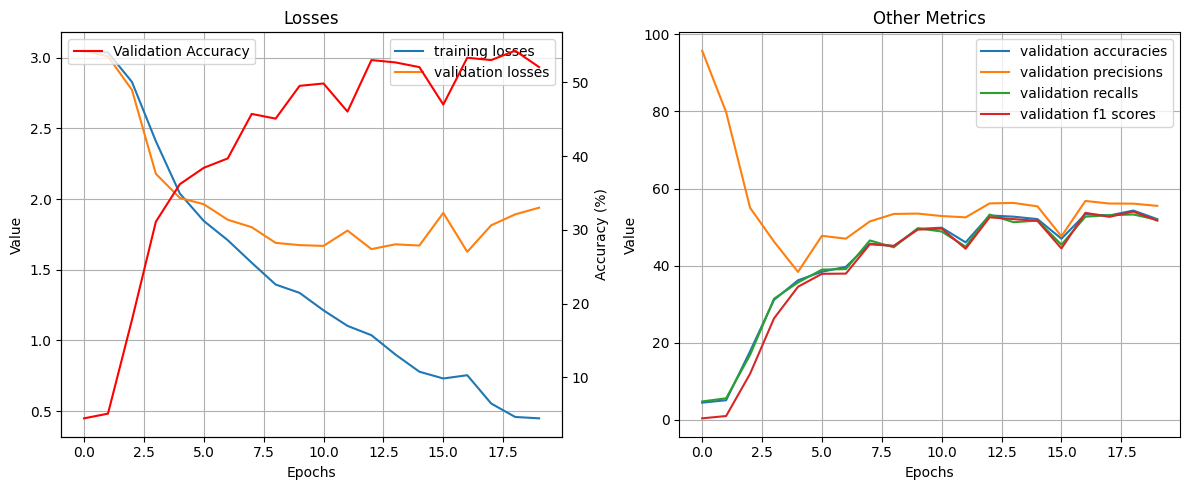

Accuracy: 66.35%, Precision: 67.08%, Recall: 66.35%, F1 Score: 65.48%


In [ ]:
visualize(metrics3)
test(even_deeper_CNN, test_loader)

This clearly helped, and we are able to find a really good model with much higher accuracy, precision, recall, and f1 score. Lets see if we can continue with this intution by making an even deeper model!

## Modifying the Convolutional Block


In [ ]:
class LargerBlocksCNN(nn.Module):
    def __init__(self, num_classes):
        super(LargerBlocksCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv10 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv11 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv12 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv13 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv14 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv15 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        # Pooling layers
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # MLP classifier
        self.fc = nn.Linear(512 * 7 * 7, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x)

        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool(x)

        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))
        x = F.relu(self.conv9(x))
        x = self.pool(x)

        x = F.relu(self.conv10(x))
        x = F.relu(self.conv11(x))
        x = F.relu(self.conv12(x))
        x = self.pool(x)

        x = F.relu(self.conv13(x))
        x = F.relu(self.conv14(x))
        x = F.relu(self.conv15(x))
        x = self.pool(x)

        x = x.view(-1, 512 * 7 * 7)  # Flatten the tensor

        x = self.fc(x)

        return x

In [ ]:
larger_blocks_CNN = LargerBlocksCNN(num_classes=num_classes).to(device)
summary(larger_blocks_CNN, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
            Conv2d-2         [-1, 64, 224, 224]          18,496
            Conv2d-3         [-1, 64, 224, 224]          36,928
         MaxPool2d-4         [-1, 64, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]          36,928
            Conv2d-6         [-1, 64, 112, 112]          36,928
            Conv2d-7        [-1, 128, 112, 112]          73,856
         MaxPool2d-8          [-1, 128, 56, 56]               0
            Conv2d-9          [-1, 128, 56, 56]         147,584
           Conv2d-10          [-1, 128, 56, 56]         147,584
           Conv2d-11          [-1, 128, 56, 56]         147,584
        MaxPool2d-12          [-1, 128, 28, 28]               0
           Conv2d-13          [-1, 256, 28, 28]         295,168
           Conv2d-14          [-1, 256,

In [ ]:
metrics4 = train(larger_blocks_CNN, train_loader, lr=0.0005, num_epochs=15)
# Load the best model after training is complete
larger_blocks_CNN.load_state_dict(torch.load('/best_model.pth'))
print("Loaded best model from:", '/best_model.pth')

Epoch 1: Improved validation accuracy to 4.13%. Model saved.
Epoch 1/15 Train Loss: 3.0462, Validation Loss: 3.0459, Accuracy: 4.13%
Epoch 2/15 Train Loss: 3.0443, Validation Loss: 3.0487, Accuracy: 3.17%
Epoch 3/15 Train Loss: 3.0443, Validation Loss: 3.0499, Accuracy: 3.17%
Epoch 4/15 Train Loss: 3.0434, Validation Loss: 3.0552, Accuracy: 3.17%
Epoch 5: Improved validation accuracy to 4.44%. Model saved.
Epoch 5/15 Train Loss: 3.0439, Validation Loss: 3.0508, Accuracy: 4.44%
Epoch 6/15 Train Loss: 3.0428, Validation Loss: 3.0579, Accuracy: 3.17%
Epoch 7/15 Train Loss: 3.0432, Validation Loss: 3.0492, Accuracy: 4.13%
Epoch 8/15 Train Loss: 3.0457, Validation Loss: 3.0489, Accuracy: 3.17%
Epoch 9/15 Train Loss: 3.0439, Validation Loss: 3.0534, Accuracy: 4.13%
Epoch 10/15 Train Loss: 3.0448, Validation Loss: 3.0508, Accuracy: 3.17%
Epoch 11/15 Train Loss: 3.0432, Validation Loss: 3.0550, Accuracy: 3.17%
Epoch 12/15 Train Loss: 3.0429, Validation Loss: 3.0543, Accuracy: 3.17%
Epoch 13/15

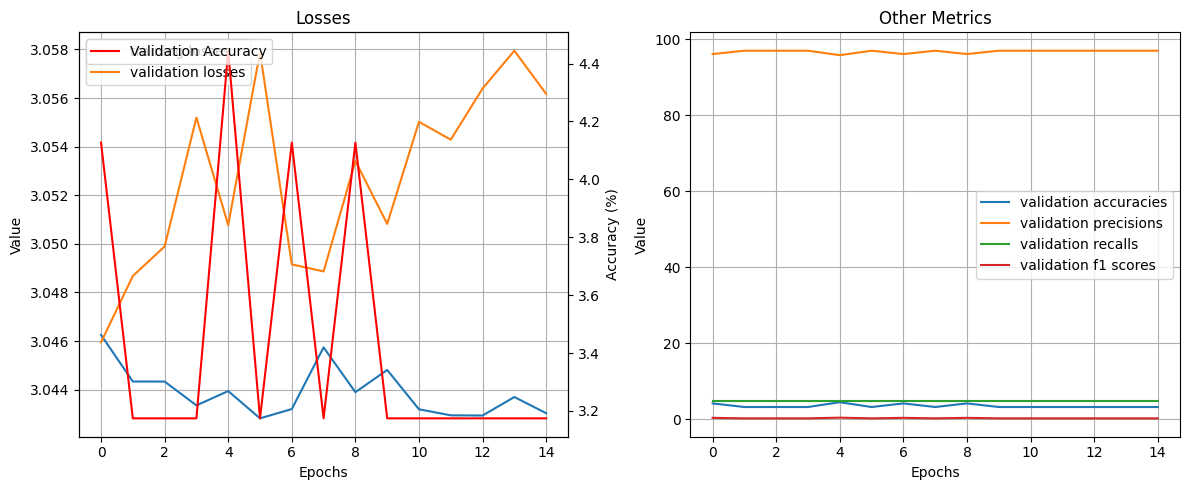

Accuracy: 3.17%, Precision: 96.93%, Recall: 3.17%, F1 Score: 0.20%


In [ ]:
visualize(metrics4)
test(larger_blocks_CNN, test_loader)

### Analysis of Larger Block CNN
This model does not seem to fit our purposes. It is a rather large and deep model, but it does not seem to be learning that well. We can explore other variations branching off of the previous model instead.

## Varying Kernel Size
We found our desired depth, now lets try to vary the kernel size and see if that helps capture larger patterns or if we should stick with 3x3 kernels.

In [ ]:
class VariedKernel(nn.Module):
    def __init__(self, num_classes):
        super(VariedKernel, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        # Pooling layers
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # MLP classifier
        self.fc = nn.Linear(512 * 7 * 7, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)

        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool(x)

        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))
        x = self.pool(x)

        x = F.relu(self.conv9(x))
        x = F.relu(self.conv10(x))
        x = self.pool(x)

        x = x.view(-1, 512 * 7 * 7)  # Flatten the tensor

        x = self.fc(x)

        return x

In [ ]:
varied_kernel_CNN = VariedKernel(num_classes=num_classes).to(device)
summary(varied_kernel_CNN, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]           2,432
            Conv2d-2         [-1, 64, 224, 224]          51,264
         MaxPool2d-3         [-1, 64, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]         102,464
            Conv2d-5         [-1, 64, 112, 112]         102,464
         MaxPool2d-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1, 128, 56, 56]          73,856
            Conv2d-8          [-1, 128, 56, 56]         147,584
         MaxPool2d-9          [-1, 128, 28, 28]               0
           Conv2d-10          [-1, 256, 28, 28]         295,168
           Conv2d-11          [-1, 256, 28, 28]         590,080
        MaxPool2d-12          [-1, 256, 14, 14]               0
           Conv2d-13          [-1, 512, 14, 14]       1,180,160
           Conv2d-14          [-1, 512,

In [ ]:
metrics5 = train(varied_kernel_CNN, train_loader, lr=0.00005, num_epochs=20)
# Load the best model after training is complete
varied_kernel_CNN.load_state_dict(torch.load('/best_model.pth'))
print("Loaded best model from:", '/best_model.pth')

Epoch 1: Improved validation accuracy to 6.67%. Model saved.
Epoch 1/20 Train Loss: 3.0456, Validation Loss: 3.0454, Accuracy: 6.67%
Epoch 2: Improved validation accuracy to 14.60%. Model saved.
Epoch 2/20 Train Loss: 3.0171, Validation Loss: 2.9229, Accuracy: 14.60%
Epoch 3: Improved validation accuracy to 15.56%. Model saved.
Epoch 3/20 Train Loss: 2.8139, Validation Loss: 2.7070, Accuracy: 15.56%
Epoch 4: Improved validation accuracy to 18.10%. Model saved.
Epoch 4/20 Train Loss: 2.5836, Validation Loss: 2.4627, Accuracy: 18.10%
Epoch 5: Improved validation accuracy to 20.63%. Model saved.
Epoch 5/20 Train Loss: 2.3405, Validation Loss: 2.2723, Accuracy: 20.63%
Epoch 6: Improved validation accuracy to 26.98%. Model saved.
Epoch 6/20 Train Loss: 2.1418, Validation Loss: 2.2902, Accuracy: 26.98%
Epoch 7: Improved validation accuracy to 33.02%. Model saved.
Epoch 7/20 Train Loss: 1.9178, Validation Loss: 2.0086, Accuracy: 33.02%
Epoch 8: Improved validation accuracy to 37.14%. Model sa

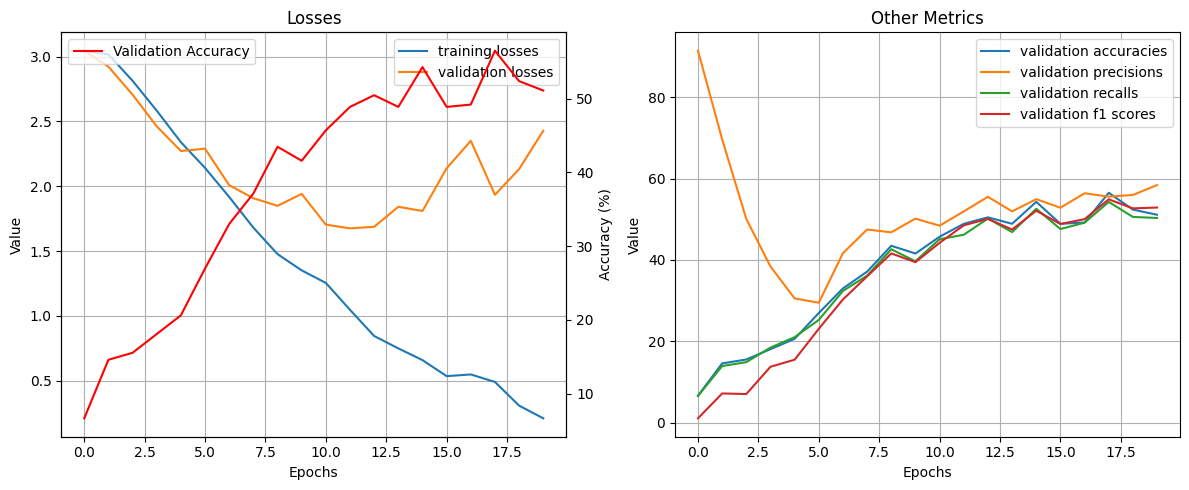

Accuracy: 67.30%, Precision: 66.95%, Recall: 67.30%, F1 Score: 65.20%


In [ ]:
visualize(metrics5)
test(varied_kernel_CNN, test_loader)

### Analysis of Larger Kernel Model
The larger kernel size did not make much of a difference, so we can stick with the EvenDeeperCNN.

# Selecting Our Optimal Model
We found that a deeper model performs better only if it has the appropriate learning rate and number of epochs, and that we can stack convolutional layers for optimal performance. We also found that too deep CNNs bring new problems, which may be detrimental without proper solutions like skip connections explored in future lectures.

Therefore, we can find that the EvenDeeperCNN with five convolutional blocks of
CONV --> CONV --> POOL
was ideal for our satellite image classification task. Note that there are many other variations to consider.

Lets plot a confusion matrix to see how this final model classifies different labels to conclude this notebook.

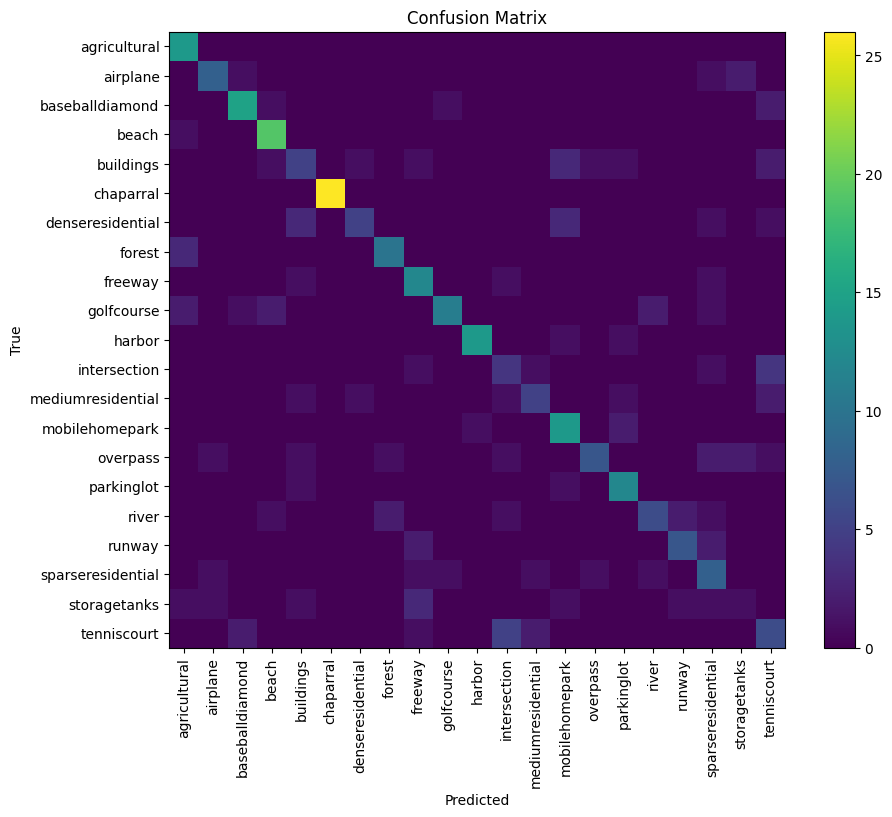

In [ ]:
from sklearn.metrics import confusion_matrix
even_deeper_CNN.eval()

true_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = even_deeper_CNN(images)
        _, predicted = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

# Convert lists to numpy arrays
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Create confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)


# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(np.arange(num_classes), label_mapping.values(), rotation=90)
plt.yticks(np.arange(num_classes), label_mapping.values())
plt.show()

# Concluding Remarks
With this confusion matrix and all the metrics we have gathered, we can continue to improve our model. However, for the purposes of this solution notebook, we have explained the intuition behind finding a more optimal model and what to look out for.